# Example 03: Precision fitting with corrections

DFT-based estimation of sinusoid parameters (frequency, amplitude, phase) carries systematic bias from spectral leakage, window discontinuities, and aliasing. When this bias dominates noise, model fitting with DFT corrections substantially reduces the total error. This notebook quantifies the improvement as a function of correction level; signal parameters are chosen so that systematic bias is the limiting factor.

*Implementation: `SineFourier` in [models/sinusoid.py](../dftmodels/models/sinusoid.py); `DFTCorrection`, `DFTCorrectionMode` in [dft/correction.py](../dftmodels/dft/correction.py).*

## Baseline methods: maximum bin and quadratic interpolation

Two simple estimators serve as a reference:

- **Maximum bin** reads the bin with the largest amplitude as the frequency estimate. Accuracy is limited to the bin spacing $\Delta f = 1/T$.
- **Quadratic interpolation** fits a parabola through the peak and its two neighbours to refine the frequency and amplitude estimates. Phase cannot be refined this way.

Both are compared against model fitting with and without DFT corrections.

In [1]:
# Baseline methods (table)
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
Path("figures").mkdir(exist_ok=True)
plt.style.use("dftmodels.mplstyle")

from dftmodels import (
    SignalSeries, NormType, WindowType, DFTRange,
    DFTCorrection, DFTCorrectionMode, SineFourier,
    Sinusoid,
)

SAMPLE_RATE     = 100.0    # Hz
DURATION        = 1.0      # s  →  bin spacing Δf = 1.0 Hz
TRUE_FREQUENCY  = 10.42    # Hz — between bins
TRUE_AMPLITUDE  = 2.0      # V
TRUE_PHASE      = 0.5      # rad
WINDOW          = WindowType.RECTANGULAR
DFT_RANGE       = DFTRange.SINGLE_SIDED
NOISE_RMS       = 0.01

ai = TRUE_AMPLITUDE * np.cos(TRUE_PHASE)
aq = TRUE_AMPLITUDE * np.sin(TRUE_PHASE)
df = 1.0 / DURATION   # bin spacing

rng = np.random.default_rng(seed=0)
t   = np.arange(0, DURATION, 1.0 / SAMPLE_RATE)
y   = Sinusoid.eval(t, ai, aq, TRUE_FREQUENCY)
y  += rng.normal(scale=NOISE_RMS, size=len(t))

signal = SignalSeries(x=t, y=y)

fourier_native = signal.calculate_dft(
    norm=NormType.ASD, window=WINDOW,
    dft_range=DFT_RANGE, pad=1.0,
)

# Maximum bin
peak_idx  = int(np.argmax(fourier_native.abs.y))
bin_freq  = fourier_native.x[peak_idx]
bin_amp   = fourier_native.abs.y[peak_idx]
bin_phase = np.angle(fourier_native.y[peak_idx])

# Quadratic interpolation (frequency and amplitude)
abs_y = fourier_native.abs.y
if 0 < peak_idx < len(abs_y) - 1:
    y_l, y_p, y_r = abs_y[peak_idx - 1], abs_y[peak_idx], abs_y[peak_idx + 1]
    delta     = 0.5 * (y_r - y_l) / (2.0 * y_p - y_l - y_r)
    quad_freq = fourier_native.x[peak_idx] + delta * df
    quad_amp  = y_p - 0.25 * (y_r - y_l) * delta
else:
    quad_freq = bin_freq
    quad_amp  = bin_amp
quad_phase = np.nan  # magnitude-only interpolation does not refine phase

mask_fit    = (fourier_native.x >= 8.0) & (fourier_native.x <= 13.0)

bare_model = SineFourier(fourier_native.dft_config, DFTCorrection(DFTCorrectionMode.NONE))
best_model = SineFourier(fourier_native.dft_config, DFTCorrection(DFTCorrectionMode.ALL, order=100))

params_fit = best_model.make_params(
    amplitude_i=ai, amplitude_q=aq,
    frequency=bin_freq + 1e-9,
    frequency_min=8.0, frequency_max=13.0,
)

best_params = best_model.fit(fourier_native, params_fit, mask=mask_fit).params
bare_params = bare_model.fit(fourier_native, params_fit, mask=mask_fit).params

print(f"Bin spacing Δf = 1/T = {df:.4f} Hz")
print(f"{'Method':<18}  {'freq err (Hz)':>14}  {'amp err (V)':>12}  {'phase err (rad)':>16}")
print("-" * 66)
print(f"{'Max bin':<18}  {abs(bin_freq  - TRUE_FREQUENCY):>14.4f}  "
      f"{abs(bin_amp   - TRUE_AMPLITUDE):>12.4f}  {abs(bin_phase  - TRUE_PHASE):>16.4f}")
print(f"{'Quad interp':<18}  {abs(quad_freq - TRUE_FREQUENCY):>14.4f}  "
      f"{abs(quad_amp  - TRUE_AMPLITUDE):>12.4f}  {abs(quad_phase - TRUE_PHASE):>16.4f}")
print()
print(f"{'★ None':<18}  {abs(bare_params["frequency"] - TRUE_FREQUENCY):>14.4f}  "
      f"{abs(bare_model.amplitude(bare_params)  - TRUE_AMPLITUDE):>12.4f}  "
      f"{abs(bare_model.phase(bare_params) - TRUE_PHASE):>16.4f}")
print(f"{'★ All':<18}  {abs(best_params["frequency"] - TRUE_FREQUENCY):>14.4f}  "
      f"{abs(best_model.amplitude(best_params)  - TRUE_AMPLITUDE):>12.4f}  "
      f"{abs(best_model.phase(best_params)  - TRUE_PHASE):>16.4f}")


Bin spacing Δf = 1/T = 1.0000 Hz
Method               freq err (Hz)   amp err (V)   phase err (rad)
------------------------------------------------------------------
Max bin                     0.4200        0.9487            0.2891
Quad interp                 0.2187        0.9697               nan

★ None                      0.0920        0.1726            0.2827
★ All                       0.0001        0.0011            0.0001


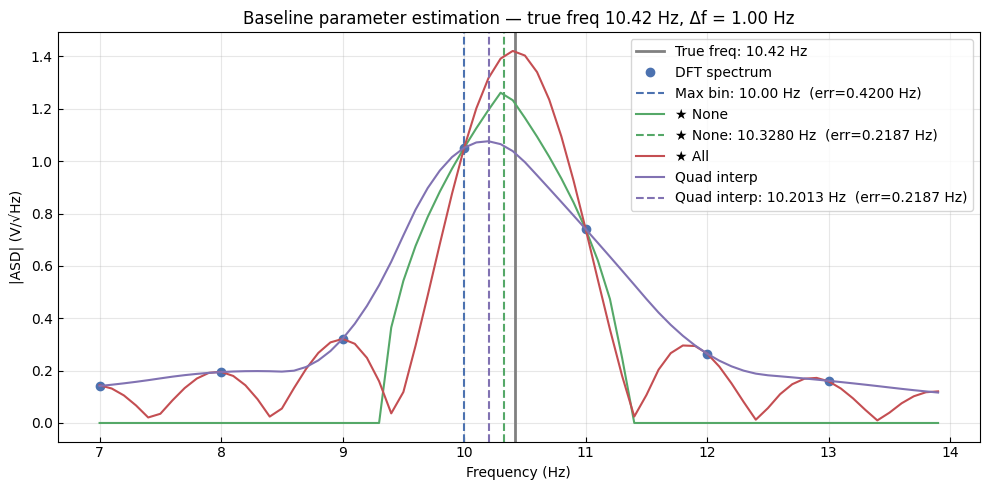

In [2]:
# Baseline methods (plot)
from scipy.interpolate import make_interp_spline

fig = plt.figure(figsize=(10, 5))

freqs = fourier_native.x
amps  = fourier_native.abs.y

freqs_fit = signal.calculate_dft(
    norm=NormType.ASD, window=WINDOW,
    dft_range=DFT_RANGE, pad=10.0,
).x

ax = plt.gca()
zoom = (freqs >= TRUE_FREQUENCY - 3.5) & (freqs <= TRUE_FREQUENCY + 3.5)

ax.axvline(TRUE_FREQUENCY, ls="-", c="grey", lw=2.0,
    label=f"True freq: {TRUE_FREQUENCY} Hz")

ax.plot(freqs[zoom], amps[zoom], ls="None", marker="o", label="DFT spectrum")
ax.axvline(bin_freq,       ls="--", c="C0",
    label=f"Max bin: {bin_freq:.2f} Hz  (err={abs(bin_freq - TRUE_FREQUENCY):.4f} Hz)")


zoom_fit = (freqs_fit >= TRUE_FREQUENCY - 3.5) & (freqs_fit <= TRUE_FREQUENCY + 3.5)
ax.plot(freqs_fit[zoom_fit], abs(bare_model.eval(bare_params, freqs_fit[zoom_fit])),
label="★ None")
ax.axvline(bare_params["frequency"].value,      ls="--", c="C1",
    label=f"★ None: {bare_params["frequency"].value:.4f} Hz  (err={abs(quad_freq - TRUE_FREQUENCY):.4f} Hz)")

ax.plot(freqs_fit[zoom_fit], abs(best_model.eval(best_params, freqs_fit[zoom_fit])),
    label="★ All")

b = make_interp_spline(fourier_native.x, abs(fourier_native.y), k=2)
ax.plot(freqs_fit[zoom_fit], abs(b(freqs_fit[zoom_fit])), label="Quad interp")
ax.axvline(quad_freq,      ls="--", c="C3",
    label=f"Quad interp: {quad_freq:.4f} Hz  (err={abs(quad_freq - TRUE_FREQUENCY):.4f} Hz)")

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("|ASD| (V/\u221aHz)")
ax.legend()
ax.set_title(f"Baseline parameter estimation — true freq {TRUE_FREQUENCY} Hz, \u0394f = {df:.2f} Hz")
plt.tight_layout()
plt.savefig(f"figures/03_precision_fitting_fig00.svg", bbox_inches="tight")
plt.show()

## Error distribution across noise realizations

300 independent noise realizations separate deterministic bias from noise-driven variance. Frequency, amplitude, and phase are tracked for all methods.

In [5]:
# Monte Carlo Simulation
CORRECTIONS = [
    ("None",  DFTCorrection(DFTCorrectionMode.NONE)),
    ("Window",  DFTCorrection(DFTCorrectionMode.WINDOW)),
    ("Baseline",  DFTCorrection(DFTCorrectionMode.BASELINE)),
    ("All", DFTCorrection(DFTCorrectionMode.ALL, order=10)),
]
PAD = 10.0
N_REALIZATIONS = 300
mc_rng = np.random.default_rng(seed=42)

t_mc   = np.arange(0, DURATION, 1.0 / SAMPLE_RATE)
y_mc   = Sinusoid.eval(t_mc, ai, aq, TRUE_FREQUENCY)
signal_mc = SignalSeries(x=t_mc, y=y_mc)

# Pre-build models once — DFT config is constant across realizations
fourier_mc = signal_mc.calculate_dft(
    norm=NormType.ASD, window=WINDOW, dft_range=DFT_RANGE, pad=PAD,
)
mc_models = [SineFourier(fourier_mc.dft_config, corr) for _, corr in CORRECTIONS]
mask_mc   = (fourier_mc.x >= 8.0) & (fourier_mc.x <= 13.0)

# Per-method error accumulators (one list per correction level)
mc_freq_errors  = [[] for _ in range(len(CORRECTIONS))]
mc_amp_errors   = [[] for _ in range(len(CORRECTIONS))]
mc_phase_errors = [[] for _ in range(len(CORRECTIONS))]

for _ in range(N_REALIZATIONS):
    y_mc   = Sinusoid.eval(t_mc, ai, aq, TRUE_FREQUENCY)
    y_mc  += mc_rng.normal(scale=NOISE_RMS, size=len(t_mc))
    sig_mc = SignalSeries(x=t_mc, y=y_mc)
    fn_mc  = sig_mc.calculate_dft(norm=NormType.ASD, window=WINDOW, dft_range=DFT_RANGE, pad=PAD)

    # Model fitting at each correction level
    for k, model in enumerate(mc_models):
        p   = model.make_params(
            amplitude_i=ai, amplitude_q=aq,
            frequency=TRUE_FREQUENCY + 1e-9,
            frequency_min=8.0, frequency_max=13.0,
        )
        p = model.fit(fn_mc, p, mask=mask_mc).params
        mc_freq_errors[k].append((model.center(p) - TRUE_FREQUENCY) * 1e3)
        mc_amp_errors[k].append((model.amplitude(p) - TRUE_AMPLITUDE) * 1e3)
        mc_phase_errors[k].append((model.phase(p) - TRUE_PHASE) * 1e3)

mc_labels = [lbl for lbl, _ in CORRECTIONS]

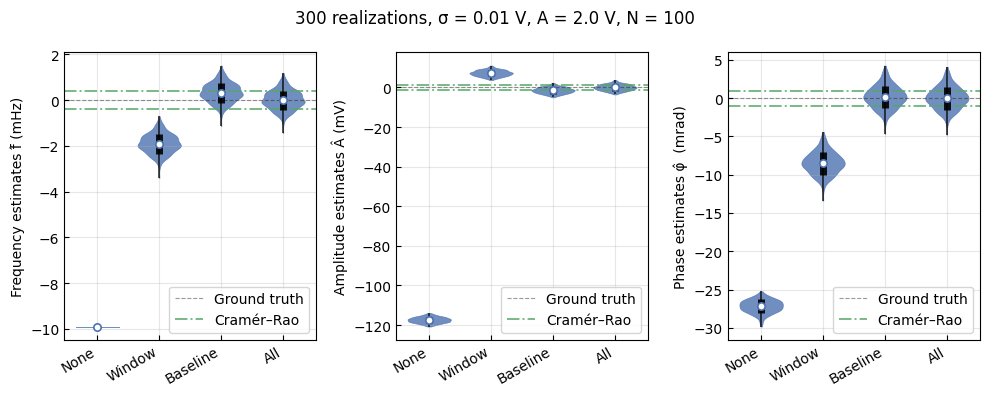

In [6]:
# Violin plots: frequency, amplitude, and phase estimation errors
from helpers import violin_panel

params_crb = SineFourier.make_params(amplitude_i=ai, amplitude_q=aq, frequency=TRUE_FREQUENCY)
_crb = Sinusoid.crb(params_crb, t_mc, NOISE_RMS)
crlb_freq  = 1e3 * _crb["frequency"]
crlb_amp   = 1e3 * _crb["amplitude"]
crlb_phase = 1e3 * _crb["phase"]

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
violin_panel(axes[0], mc_freq_errors,  mc_labels,  crb=crlb_freq,
             ylabel="Frequency estimates f̂ (mHz)")
violin_panel(axes[1], mc_amp_errors,   mc_labels,   crb=crlb_amp,
             ylabel="Amplitude estimates Â (mV)")
violin_panel(axes[2], mc_phase_errors, mc_labels, crb=crlb_phase,
             ylabel="Phase estimates φ̂  (mrad)")
plt.suptitle(f"{N_REALIZATIONS} realizations, σ = {NOISE_RMS} V, A = {TRUE_AMPLITUDE} V, N = {len(y_mc)}")
plt.tight_layout()
plt.savefig(f"figures/03_precision_fitting_fig01.svg", bbox_inches="tight")
plt.show()

## Noise floor and the Cramér–Rao bound

Each violin plot shows two reference lines: the **noise floor** and the **Cramér–Rao bound (CRB)**.

**Noise floor.** Once systematic bias has been eliminated by corrections, the remaining scatter across realizations is purely noise-driven. Its standard deviation

$$\sigma_{\mathrm{floor}} = \mathrm{std}\!\left(\hat{\theta}_k - \theta_0\right)_{k=1}^{N_{\mathrm{MC}}}$$

is what a good, bias-free estimator actually achieves on this dataset.

**Cramér–Rao bound.** The CRB is the minimum variance any *unbiased* estimator can attain for a given model and noise level. It follows from the Fisher information matrix (FIM). Consider the signal

$$x_n = a_i \cos(2\pi f\, n T_s) + a_q \sin(2\pi f\, n T_s) + w_n, \qquad w_n \sim \mathcal{N}(0,\,\sigma^2),$$

with $N$ samples at spacing $T_s = 1/f_s$. The log-likelihood is $\ell \propto -\tfrac{1}{2\sigma^2}\sum_n (x_n - \mu_n)^2$, and the FIM diagonal elements are $J_{\theta\theta} = \sigma^{-2}\sum_n (\partial\mu_n/\partial\theta)^2$.

*Amplitude components.* The partial derivatives $\partial\mu_n/\partial a_i = \cos(2\pi f n T_s)$ and $\partial\mu_n/\partial a_q = \sin(2\pi f n T_s)$ are unit-amplitude sinusoids, so their squared sums average to $N/2$ for $f \gg 1/T$:

$$J_{a_i} = J_{a_q} = \frac{N}{2\sigma^2}.$$

Error propagation from $(a_i, a_q)$ to amplitude $A = \sqrt{a_i^2 + a_q^2}$ and phase $\varphi = \mathrm{atan2}(a_q, a_i)$ gives

$$\sigma_A = \sigma\sqrt{\frac{2}{N}}, \qquad \sigma_\varphi = \frac{\sigma}{A}\sqrt{\frac{2}{N}}.$$

These expressions assume frequency is known. When frequency is simultaneously estimated, the off-diagonal coupling between $f$ and $(a_i, a_q)$ in the full $3\times3$ FIM increases the marginal phase variance. The Schur complement shows that $\sigma_\varphi$ is approximately doubled:

$$\sigma_\varphi^{(\text{freq free})} \approx 2\,\sigma_\varphi = \frac{2\sigma}{A}\sqrt{\frac{2}{N}}.$$

The violin plots therefore show phase scatter roughly twice the CRB line — this is expected and does not indicate a suboptimal estimator. Amplitude estimates are unaffected by this coupling and reach the bound directly.

*Frequency.* The derivative $\partial\mu_n/\partial f = 2\pi n T_s(-a_i \sin(\cdot) + a_q \cos(\cdot))$ grows linearly with sample index $n$. Summing its square and using $\sum_{n=0}^{N-1} n^2 \sin^2(\cdot) \approx N^3/6$ for large $N$:

$$J_f = \frac{A^2 (2\pi T_s)^2 N^3}{6\sigma^2}.$$

Inverting the full $3\times3$ FIM and writing $T = N T_s$ yields the Rife–Boorstyn bound:

$$\sigma_f = \frac{\sigma\sqrt{6}}{\pi A T \sqrt{N}}.$$

The denominator has $\pi$ rather than $2\pi$ because the off-diagonal coupling between $f$ and $(a_i, a_q)$ in the FIM doubles the marginal frequency variance relative to the diagonal-only result $1/J_f$ (Schur complement of the amplitude block).

## Fit stderr vs Monte Carlo std vs CRB

The fit covariance matrix provides a per-fit uncertainty estimate (`amplitude_stderr`, `phase_stderr`, `center_stderr`). When the model is correct and bias-free, this estimate should match the MC std. For a biased model the covariance is dominated by the systematic error and may not be meaningful.

*Implementation: `SineFourier.amplitude_stderr`, `SineFourier.phase_stderr`, `SineFourier.center_stderr` in [models/sinusoid.py](../dftmodels/models/sinusoid.py).*

In [7]:
# Comparison uncertainty estimates vs monte carlo (table)
def rmse(errors):
    return np.sqrt(np.mean(np.array(errors) ** 2))

# RMSE across MC realizations
rmse_freq_bare  = rmse(mc_freq_errors[0]);   rmse_freq_best  = rmse(mc_freq_errors[-1])
rmse_amp_bare   = rmse(mc_amp_errors[0]);    rmse_amp_best   = rmse(mc_amp_errors[-1])
rmse_phase_bare = rmse(mc_phase_errors[0]);  rmse_phase_best = rmse(mc_phase_errors[-1])

# Fit stderr from a single realization (covariance-based estimate)
bare_freq_stderr  = bare_model.center_stderr(bare_params)    * 1e3
bare_amp_stderr   = bare_model.amplitude_stderr(bare_params) * 1e3
bare_phase_stderr = bare_model.phase_stderr(bare_params)     * 1e3

best_freq_stderr  = best_model.center_stderr(best_params)    * 1e3
best_amp_stderr   = best_model.amplitude_stderr(best_params) * 1e3
best_phase_stderr = best_model.phase_stderr(best_params)     * 1e3

hdr = f"{'':28}  {'freq (mHz)':>12}  {'amp (mV)':>10}  {'phase (mrad)':>14}"
sep = "-" * len(hdr)
print(hdr)
print(sep)
print(f"{'CRB':<28}  {crlb_freq:>12.2f}  {crlb_amp:>10.2f}  {crlb_phase:>14.2f}")
print(sep)
print(f"{'Sinc only           RMSE':<28}  {rmse_freq_bare:>12.2f}  {rmse_amp_bare:>10.2f}  {rmse_phase_bare:>14.2f}")
print(f"{'              fit stderr':<28}  {bare_freq_stderr:>12.2f}  {bare_amp_stderr:>10.2f}  {bare_phase_stderr:>14.2f}")
print(sep)
print(f"{'Sinc + corrections  RMSE':<28}  {rmse_freq_best:>12.2f}  {rmse_amp_best:>10.2f}  {rmse_phase_best:>14.2f}")
print(f"{'              fit stderr':<28}  {best_freq_stderr:>12.2f}  {best_amp_stderr:>10.2f}  {best_phase_stderr:>14.2f}")

                                freq (mHz)    amp (mV)    phase (mrad)
----------------------------------------------------------------------
CRB                                   0.39        1.41            0.98
----------------------------------------------------------------------
Sinc only           RMSE              9.90      117.38           27.18
              fit stderr            121.43      309.20          382.05
----------------------------------------------------------------------
Sinc + corrections  RMSE              0.41        1.47            1.43
              fit stderr              0.40        2.09            1.26


## Summary

- **Corrections eliminate systematic bias** — without them, systematic artefacts limit accuracy just like naive methods, regardless of SNR.
- **More corrections = better results**, monotonically, as long as bias dominates. Once noise takes over, the margin between correction levels narrows (as visible in the violin plots).
- **The gains shown here are large because this example was designed that way** — the frequency sits far from a bin center and noise is very low, so systematic bias is the bottleneck. In practice, improvements scale with how much bias contributes relative to noise.
- **Frequency and amplitude estimates approach their Cramér–Rao bounds.** Phase estimates are approximately a factor of two above the bound — expected when frequency is simultaneously estimated; the off-diagonal coupling in the Fisher information matrix roughly doubles the marginal phase variance relative to the fixed-frequency case.